## Modelo GMM

### ¿Qué es el modelo GMM (Gaussian Mixture Model)?

**Gaussian Mixture Model (GMM)** es un modelo probabilístico de clustering que asume que los datos provienen de una mezcla de varias distribuciones gaussianas (normales). A diferencia de algoritmos de clustering como K-Means, que asignan cada punto a un único cluster de forma determinista, GMM proporciona:

- **Asignación probabilística**: Cada punto de datos tiene una probabilidad de pertenecer a cada cluster, lo que permite manejar casos ambiguos donde un cliente podría pertenecer parcialmente a varios grupos.

- **Flexibilidad en la forma de los clusters**: Los clusters pueden tener formas elípticas (no solo esféricas como en K-Means), lo que permite capturar mejor la estructura real de los datos.

- **Modelo generativo**: GMM puede generar nuevos datos similares a los observados, lo que es útil para análisis de simulación y detección de anomalías.

El modelo estima parámetros para cada componente gaussiana:
- **Media (μ)**: Centro del cluster
- **Covarianza (Σ)**: Forma y orientación del cluster
- **Pesos (π)**: Proporción de datos que pertenecen a cada cluster

## Parámetros de GaussianMixture y su Efecto

### Parámetros Principales de GaussianMixture

A continuación se explican los parámetros más importantes que puedes ajustar en sklearn.mixture.GaussianMixture:

#### 1. *n_components* (int, default=1)
- *Qué hace*: Número de componentes gaussianos (clusters) en la mezcla.
- *Efecto*:
  - Valores bajos (2-3): Menos clusters, más generalización, puede perder detalles.
  - Valores altos (8-10+): Más clusters, puede sobreajustar, clusters muy pequeños.
  - *Recomendación*: Usar métricas como AIC, BIC o Silhouette para elegir el número óptimo.
- *Ejemplo*: n_components=5 → 5 clusters

#### 2. *covariance_type* (str, default='full')
- *Opciones*: 'full', 'tied', 'diag', 'spherical'
- *Qué hace*: Controla la forma y flexibilidad de las matrices de covarianza:
  - *'full'*: Cada componente tiene su propia matriz de covarianza completa (más flexible, más parámetros).
  - *'tied'*: Todos los componentes comparten la misma matriz de covarianza (más restrictivo, menos parámetros).
  - *'diag'*: Solo diagonal (covarianzas independientes por dimensión).
  - *'spherical'*: Covarianza esférica (igual varianza en todas las direcciones, como K-Means).
- *Efecto*:
  - 'full': Clusters elípticos orientados en cualquier dirección (más realista pero más complejo).
  - 'spherical': Clusters circulares (más simple, similar a K-Means).


#### 3. *tol* (float, default=1e-3)
- *Qué hace*: Tolerancia para la convergencia del algoritmo EM.
- *Efecto*:
  - Valores más bajos (1e-6): Convergencia más estricta, más iteraciones, más preciso.
  - Valores más altos (1e-2): Convergencia más rápida, menos iteraciones, menos preciso.

#### 4. *max_iter* (int, default=100)
- *Qué hace*: Número máximo de iteraciones del algoritmo EM.
- *Efecto*:
  - Valores bajos: Puede no converger, solución subóptima.
  - Valores altos: Más tiempo de cómputo, pero asegura convergencia.

#### 5. *n_init* (int, default=1)
- *Qué hace*: Número de inicializaciones diferentes del algoritmo.
- *Efecto*:
  - n_init=1: Una sola inicialización (rápido pero puede quedar atrapado en mínimo local).
  - n_init=10: Prueba 10 inicializaciones y elige la mejor (más robusto pero más lento).

#### 6. *init_params* (str, default='kmeans')
- *Opciones*: 'kmeans', 'k-means++', 'random', 'random_from_data'
- *Qué hace*: Método de inicialización de los parámetros del modelo:
  - *'kmeans'*: Usa K-Means para inicializar (rápido y generalmente bueno).
  - *'k-means++'*: Versión mejorada de K-Means (mejor que 'kmeans').
  - *'random'*: Inicialización aleatoria completa.
  - *'random_from_data'*: Selecciona puntos aleatorios de los datos como centros iniciales.
- *Efecto*:
  - 'kmeans' o 'k-means++': Generalmente mejores resultados iniciales.
  - 'random': Más variabilidad, útil para explorar diferentes soluciones.

#### 7. *random_state* (int, default=None)
- *Qué hace*: Semilla para la generación de números aleatorios.
- *Efecto*:
  - None: Resultados diferentes en cada ejecución.
  - int (ej: 42): Resultados reproducibles.

#### 8. *warm_start* (bool, default=False)
- *Qué hace*: Si es True, reutiliza la solución anterior como inicialización.
- *Efecto*:
  - False: Cada fit() empieza desde cero.
  - True: Útil para entrenamiento iterativo o ajuste fino.

#### 9. *reg_covar* (float, default=1e-6)
- *Qué hace*: Regularización añadida a la diagonal de las matrices de covarianza.
- *Efecto*:
  - Valores muy bajos: Puede causar problemas numéricos si hay clusters pequeños.
  - Valores más altos: Más estabilidad numérica pero menos precisión.

#### 10. *weights_init, *means_init*, *precisions_init** (arrays, default=None)
- *Qué hace*: Permiten inicializar manualmente los pesos, medias y precisiones.
- *Efecto*: Control total sobre la inicialización si conoces la estructura de los datos.

---

### Resumen de Parámetros Más Importantes

| Parámetro | Valores Típicos | Impacto |
|-----------|----------------|---------|
| n_components | 2-10 | *ALTO* - Define número de clusters |
| covariance_type | 'full', 'spherical' | *ALTO* - Define forma de clusters |
| n_init | 1-10 | *MEDIO* - Estabilidad del resultado |
| init_params | 'k-means++', 'random' | *MEDIO* - Calidad inicial |
| tol | 1e-6 a 1e-2 | *BAJO* - Precisión de convergencia |
| max_iter | 100-300 | *BAJO* - Tiempo de cómputo |
| random_state | int o None | *BAJO* - Reproducibilidad |

---

Ejemplo de Configuración Recomendada

##### Configuración equilibrada (buen balance entre calidad y velocidad)
gmm = GaussianMixture(
    n_components=5,           # Número de clusters
    covariance_type='full',   # Clusters elípticos flexibles
    n_init=10,                # 10 inicializaciones para robustez
    init_params='k-means++',  # Inicialización inteligente
    max_iter=200,             # Suficientes iteraciones
    tol=1e-3,                 # Tolerancia estándar
    random_state=42           # Reproducibilidad
)

##### Configuración rápida (para pruebas rápidas)
gmm_fast = GaussianMixture(
    n_components=5,
    covariance_type='spherical',  # Más simple, más rápido
    n_init=1,                      # Una sola inicialización
    random_state=42
)

##### Configuración precisa (para análisis final)
gmm_precise = GaussianMixture(
    n_components=5,
    covariance_type='full',
    n_init=20,                     # Más inicializaciones
    init_params='k-means++',
    max_iter=500,                  # Más iteraciones
    tol=1e-6,                      # Tolerancia más estricta
    random_state=42
)

### IMPORTS

In [4]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpl_patches
import matplotlib.gridspec as gridspec
import warnings
import os
import imageio.v2 as imageio
import seaborn as sns

### Carga de datos

In [5]:
data_std = pd.read_csv('./Mall_Customers_Standardized.csv')

### Modelo GGM 2 variables

In [6]:
X = data_std.values

# Usar solo Annual Income y Spending Score (variables estandarizadas)
X_2d = data_std[['Annual Income (k$)', 'Spending Score (1-100)']].values
print(f"Forma de los datos (solo Income + Spending Score): {X_2d.shape}")
print(f"Primeras 5 filas:\n{data_std.head()}")

Forma de los datos (solo Income + Spending Score): (200, 2)
Primeras 5 filas:
        Age  Annual Income (k$)  Spending Score (1-100)
0 -1.424569           -1.738999               -0.434801
1 -1.281035           -1.738999                1.195704
2 -1.352802           -1.700830               -1.715913
3 -1.137502           -1.700830                1.040418
4 -0.563369           -1.662660               -0.395980


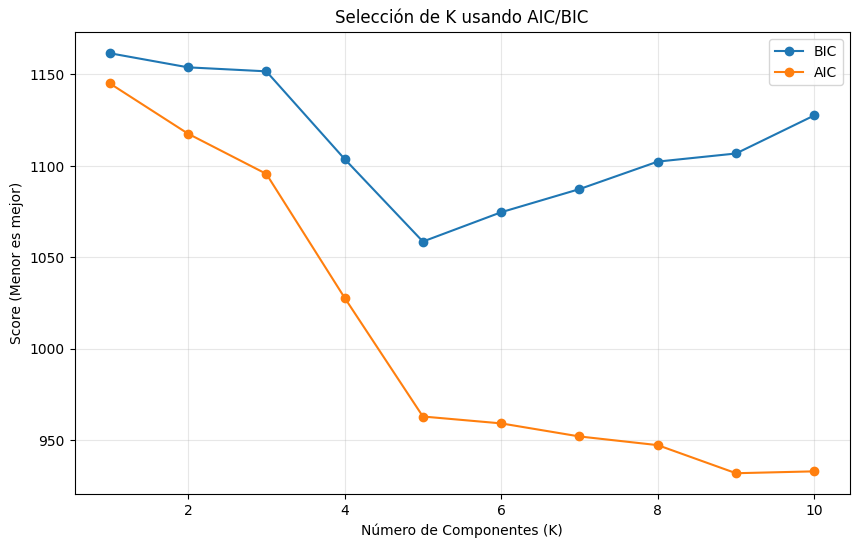

In [7]:
# Cáculo de AIC y BIC para elegir K
n_components = np.arange(1, 11)
models = [GaussianMixture(n, covariance_type='full', random_state=42).fit(X_2d)
          for n in n_components]

plt.figure(figsize=(10, 6))
plt.plot(n_components, [m.bic(X_2d) for m in models], label='BIC', marker='o')
plt.plot(n_components, [m.aic(X_2d) for m in models], label='AIC', marker='o')
plt.legend(loc='best')
plt.xlabel('Número de Componentes (K)')
plt.ylabel('Score (Menor es mejor)')
plt.title('Selección de K usando AIC/BIC')
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
print("MODELO GMM - Parámetros por defecto (Annual Income + Spending Score)")

gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_2d)

MODELO GMM - Parámetros por defecto (Annual Income + Spending Score)


,"n_components n_components: int, default=1The number of mixture components.",5
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [9]:
# Predicciones y probabilidades
labels = gmm.predict(X_2d)
probs = gmm.predict_proba(X_2d)

In [11]:
# Métricas de evaluación
silhouette = silhouette_score(X_2d, labels)
calinski = calinski_harabasz_score(X_2d, labels)
davies = davies_bouldin_score(X_2d, labels)
aic = gmm.aic(X_2d)
bic = gmm.bic(X_2d)
log_likelihood = gmm.score(X_2d) * len(X_2d)

print(f"Número de componentes: {gmm.n_components}")
print(f"Covariance type: {gmm.covariance_type}")
print(f"Convergió: {gmm.converged_}")
print(f"Iteraciones: {gmm.n_iter_}")
print(f"\nMétricas:")
print(f"  - Silhouette Score: {silhouette:.4f}")
print(f"  - Calinski-Harabasz Score: {calinski:.4f}")
print(f"  - Davies-Bouldin Score: {davies:.4f}")
print(f"  - AIC: {aic:.4f}")
print(f"  - BIC: {bic:.4f}")
print(f"  - Log Likelihood: {log_likelihood:.4f}")

Número de componentes: 5
Covariance type: full
Convergió: True
Iteraciones: 5

Métricas:
  - Silhouette Score: 0.5537
  - Calinski-Harabasz Score: 244.9402
  - Davies-Bouldin Score: 0.5760
  - AIC: 963.0010
  - BIC: 1058.6523
  - Log Likelihood: -452.5005


"La evaluación cuantitativa del modelo GMM con $K=5$ arroja resultados muy sólidos. Se obtuvo un Silhouette Score de 0.55, superando el umbral de 0.5 que denota una estructura de clustering fuerte. Asimismo, el índice Davies-Bouldin de 0.57 (bajo) confirma que los segmentos son compactos y están bien diferenciados entre sí.Adicionalmente, la rápida convergencia del algoritmo (solo 5 iteraciones) sugiere que la partición en 5 grupos es la estructura natural subyacente en el comportamiento de los clientes, validando la robustez de la segmentación propuesta."

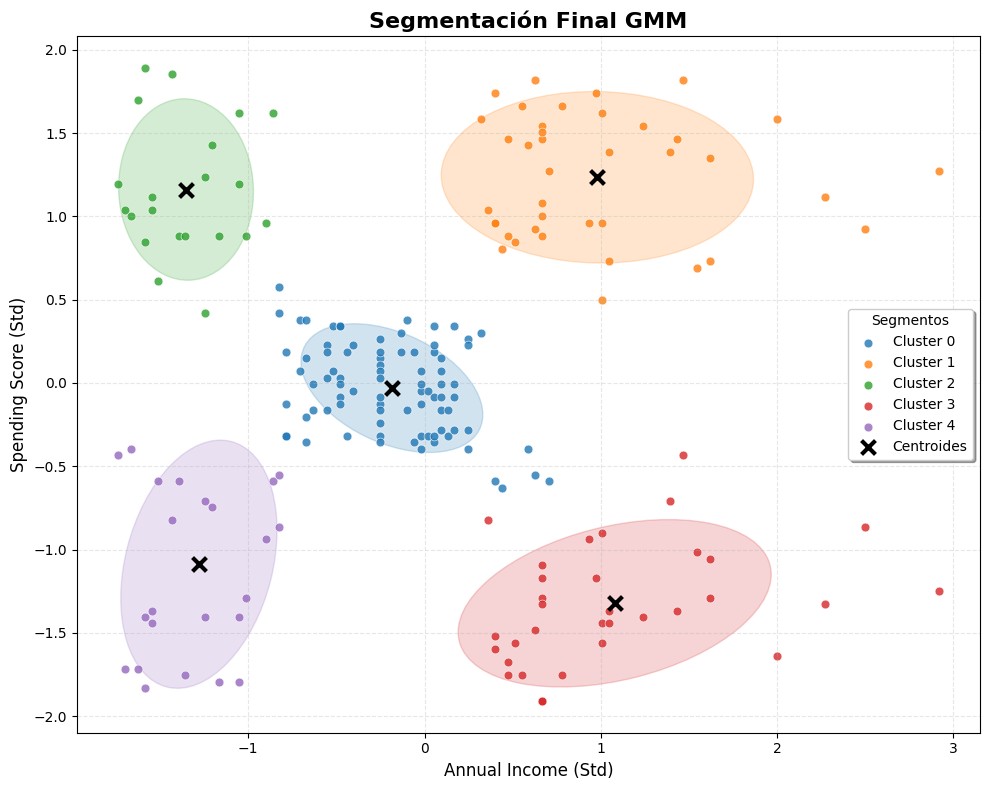

In [ ]:

fig, ax = plt.subplots(figsize=(10, 8))

# 1. Definir colores distintos (Cualitativos)
colors = plt.cm.tab10(np.arange(5))

# 2. Función para dibujar elipses
def draw_ellipses(gmm, ax):
    for n, (mean, covar) in enumerate(zip(gmm.means_, gmm.covariances_)):
        if gmm.covariance_type == 'full': cov = covar[:2, :2]
        elif gmm.covariance_type == 'tied': cov = gmm.covariances_[:2, :2]
        elif gmm.covariance_type == 'diag': cov = np.diag(covar[:2])
        else: cov = np.eye(gmm.means_.shape[1]) * covar

        v, w = np.linalg.eigh(cov)
        u = w[0] / np.linalg.norm(w[0])
        angle = np.arctan2(u[1], u[0]) * 180 / np.pi
        v = 2. * np.sqrt(2.) * np.sqrt(v)

        ell = mpl_patches.Ellipse(mean, v[0], v[1], angle=180+angle, color=colors[n])
        ell.set_clip_box(ax.bbox)
        ell.set_alpha(0.2) 
        ax.add_artist(ell)

# 3. Dibujar las elipses 
draw_ellipses(gmm, ax)

# 4. Dibujar los puntos ENCIMA
# Usamos un bucle para poder crear la leyenda correctamente
for i in range(5):
    points = X_2d[labels == i]
    ax.scatter(points[:, 0], points[:, 1], s=40, color=colors[i], label=f'Cluster {i}', alpha=0.8, edgecolors='white', linewidth=0.5)

# 5. Dibujar los CENTROIDES (La X negra)
ax.scatter(gmm.means_[:, 0], gmm.means_[:, 1], marker='x', s=100, linewidths=3, color='black', zorder=10, label='Centroides')

# Decoración
plt.title('Segmentación Final GMM', fontsize=16, fontweight='bold')
plt.xlabel('Annual Income (Std)', fontsize=12)
plt.ylabel('Spending Score (Std)', fontsize=12)
plt.legend(title="Segmentos", loc='best', frameon=True, fancybox=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

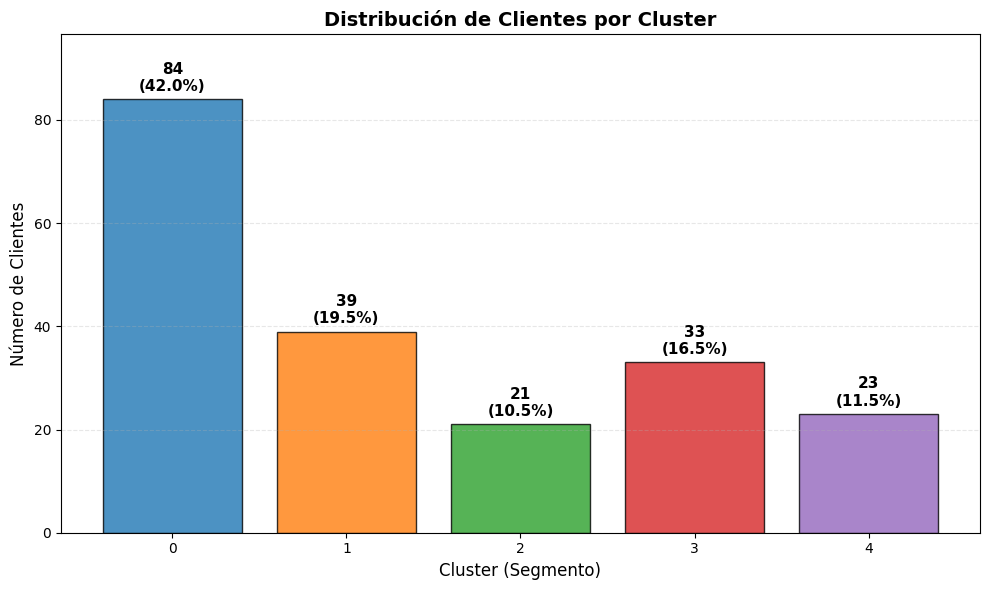

In [13]:
counts = pd.Series(labels).value_counts().sort_index()
plt.figure(figsize=(10, 6))

colors = plt.cm.tab10(np.arange(len(counts)))
bars = plt.bar(counts.index, counts.values, color=colors, alpha=0.8, edgecolor='black')

plt.xlabel('Cluster (Segmento)', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.title('Distribución de Clientes por Cluster', fontsize=14, fontweight='bold')
plt.xticks(counts.index) # Asegurar que salen todos los números (0, 1, 2...)
plt.grid(axis='y', linestyle='--', alpha=0.3)

total = sum(counts.values)
for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{int(height)}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Ajustar límite superior para que quepa el texto
plt.ylim(0, max(counts.values) * 1.15)

plt.tight_layout()
plt.show()

Vale perfecto, ahora para ver como funciona realmente este algoritmo, que su gracia es esa capacidad de adaptarse a la forma de los datos con el algoritmo EM que antes ha explicado perfectamente Emilio, hemos decidido crear una simulacion donde en vez de empezar el algoritmo con el init_params=kmeans hemos elegido la semilla 2 para ver como el algoritmo aprende des de cero.

Aqui podemos ver como los centroides se inicializan muy cerca y van cogiendo su forma final en los nucleos de los clusters. Y tambien se puede ver mucho mejor en el gif que hemos creado con estas iteraciones como las formas se van moviendo para capturar la dispersion final de cada grupo.

# Visualización de la Dinámica de Convergencia: El Algoritmo EM paso a paso

Una de las grandes ventajas de los Modelos de Mezcla Gaussiana (GMM) es su capacidad para adaptarse a la forma de los datos mediante el algoritmo **Expectation-Maximization (EM)**. Para comprender realmente cómo funciona este proceso iterativo, no basta con ver el resultado final; es necesario observar la evolución del modelo desde el caos inicial hasta la estabilidad.

### ¿Qué vamos a hacer?
En la siguiente simulación, forzaremos al algoritmo a aprender "desde cero" utilizando una **inicialización aleatoria** (`init_params='random'`). A diferencia de la inicialización estándar (que usa K-Means y converge casi instantáneamente), esto nos permitirá visualizar el "viaje" de los clusters a través del espacio de datos.

### ¿Qué observar en los gráficos?
Generaremos una secuencia de imágenes que capturan el estado del modelo en diferentes iteraciones. Preste atención a dos fenómenos clave:
1.  **El desplazamiento de los Centroides (X):** Veremos cómo viajan desde posiciones aleatorias hasta los núcleos de densidad de los clientes.
2.  **La deformación de las Covarianzas (Elipses):** Observaremos cómo las formas circulares iniciales se estiran, rotan y cambian de tamaño para capturar la dispersión específica de cada grupo (la correlación entre Ingresos y Gasto).

Este experimento visual demuestra cómo el algoritmo maximiza iterativamente la verosimilitud (Log-Likelihood) ajustando los parámetros $\mu$ (medias) y $\Sigma$ (covarianzas).

In [15]:
# Función auxiliar para pintar elipses
def make_ellipses(gmm, ax):
    for n, (mean, covar, weight) in enumerate(zip(gmm.means_, gmm.covariances_, gmm.weights_)):
        if gmm.covariance_type == 'full': covariances = covar[:2, :2]
        elif gmm.covariance_type == 'tied': covariances = gmm.covariances_[:2, :2]
        elif gmm.covariance_type == 'diag': covariances = np.diag(covar[:2])
        elif gmm.covariance_type == 'spherical': covariances = np.eye(gmm.means_.shape[1]) * covar
        v, w = np.linalg.eigh(covariances)
        u = w[0] / np.linalg.norm(w[0])
        angle = np.arctan2(u[1], u[0])
        angle = 180 * angle / np.pi
        v = 2. * np.sqrt(2.) * np.sqrt(v)
        # Dibujar
        ell = mpl_patches.Ellipse(mean, v[0], v[1], angle=180 + angle, color=plt.cm.tab10(n))
        ell.set_clip_box(ax.bbox)
        ell.set_alpha(0.3)
        ax.add_artist(ell)
        ax.set_aspect('equal', 'datalim')

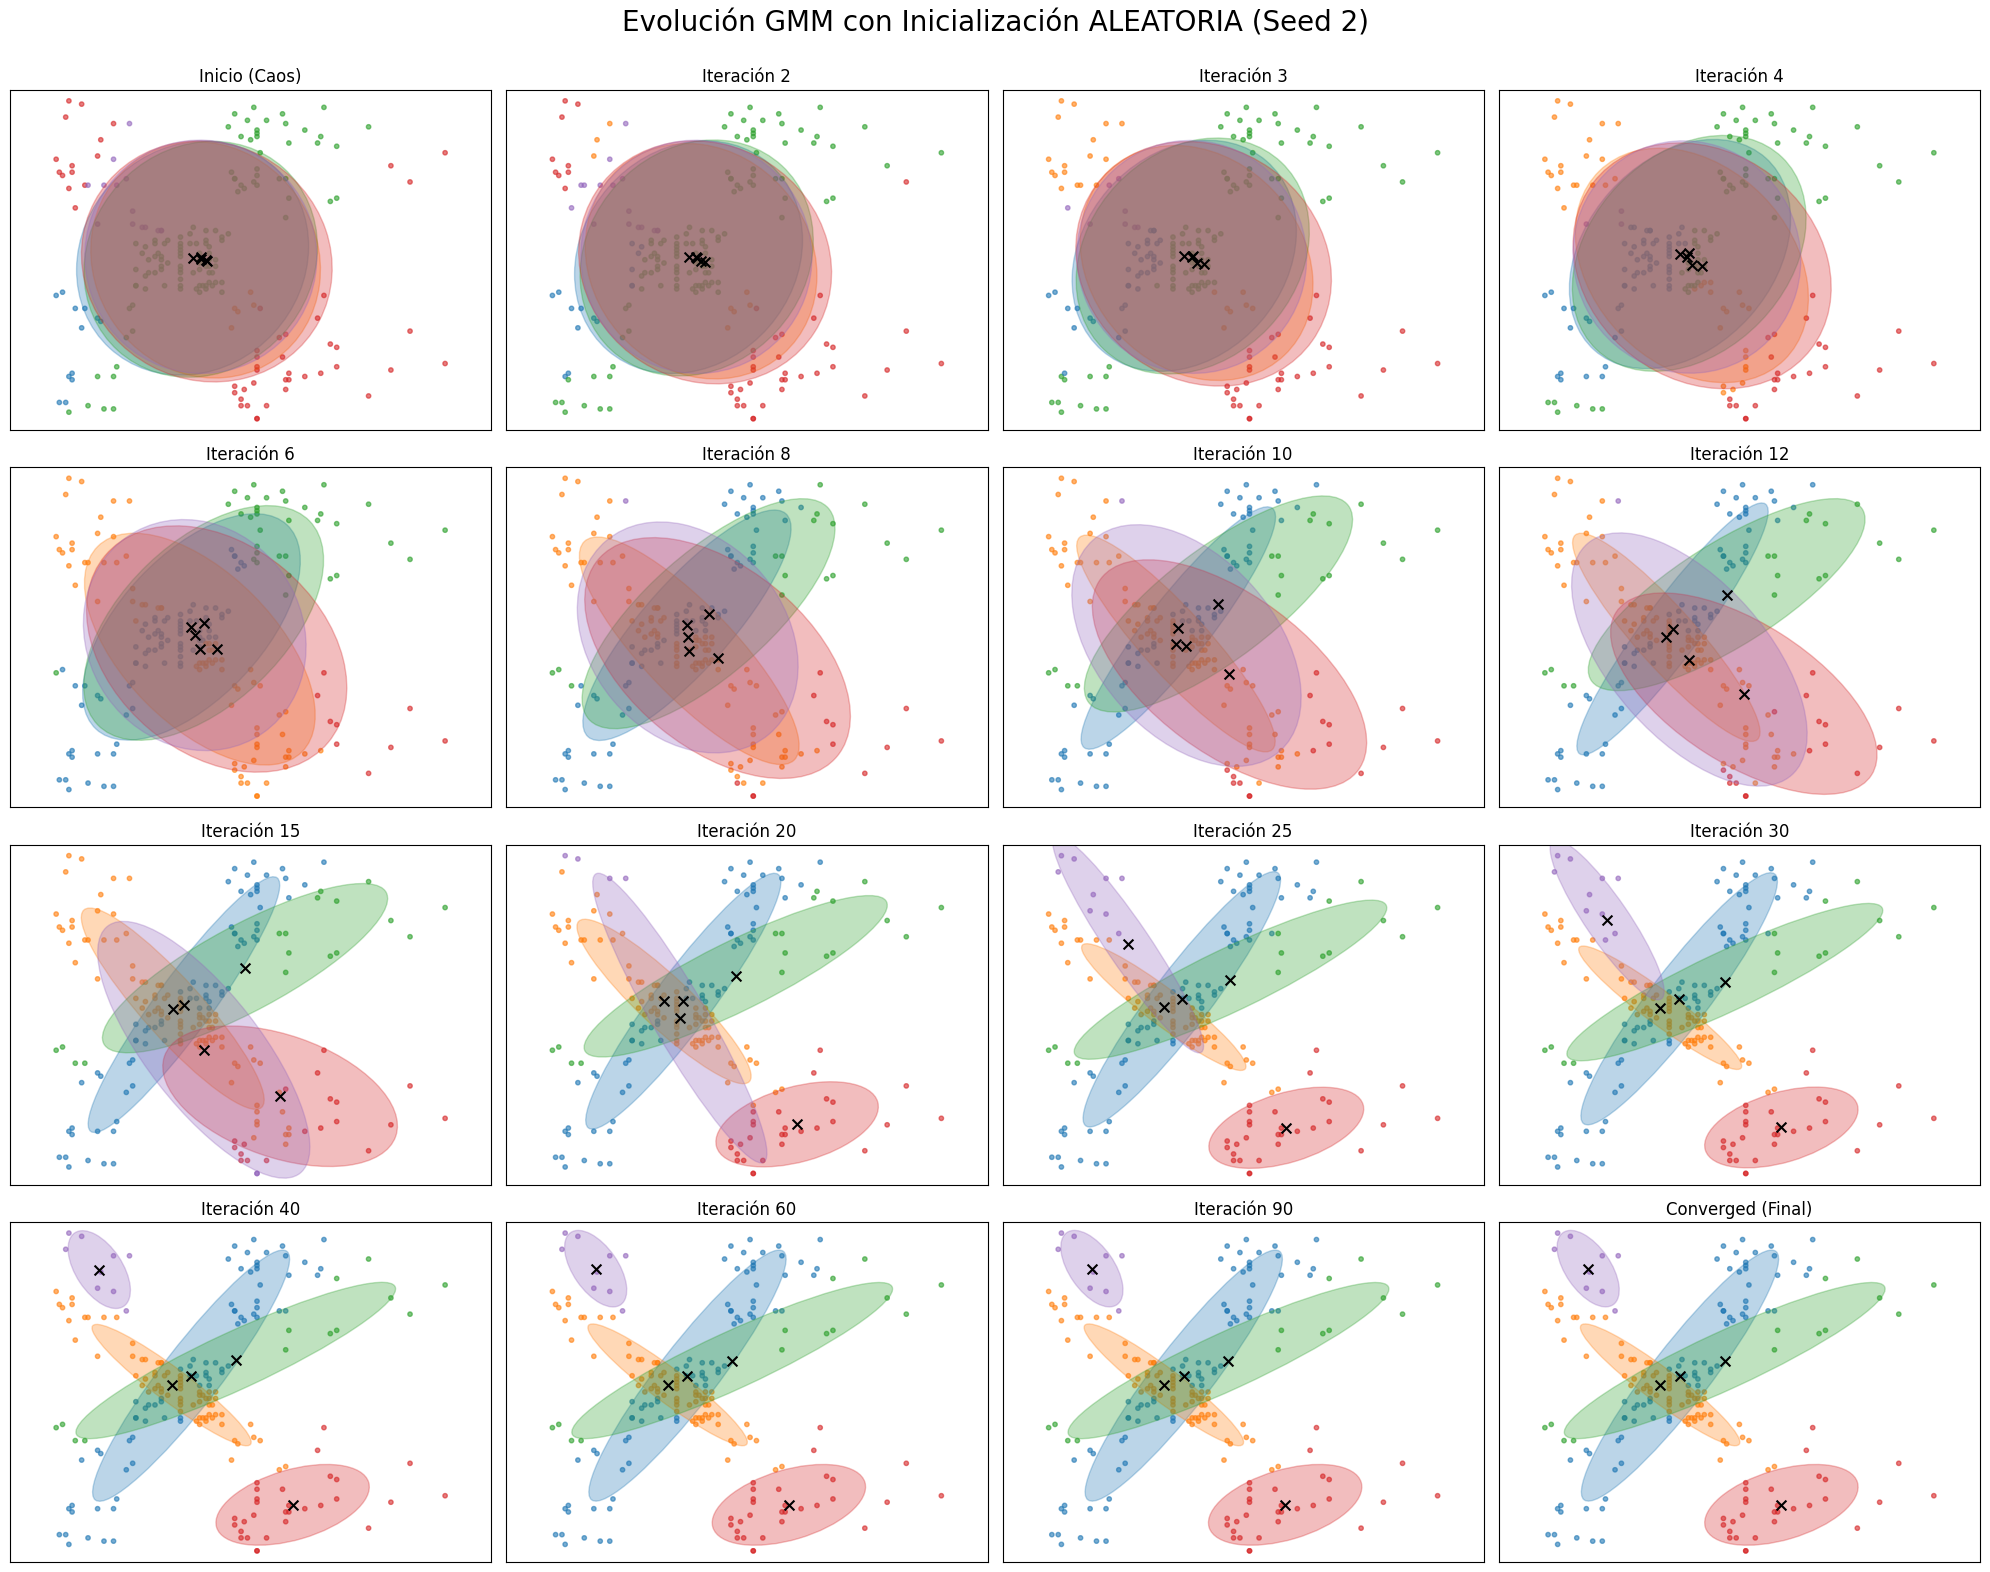

In [17]:

SEMILLA = 2
frames_to_show = [1, 2, 3, 4, 6, 8, 10, 12, 15, 20, 25, 30, 40, 60, 90, 120]
n_rows, n_cols = 4, 4

gmm_rand = GaussianMixture(n_components=5, random_state=SEMILLA,
                           warm_start=True, max_iter=1, init_params='random')

plt.figure(figsize=(20, 16))
current_iter = 0
plot_idx = 1

# Bucle de entrenamiento y visualización
while plot_idx <= len(frames_to_show):
    gmm_rand.fit(X_2d)
    current_iter += 1

    if current_iter in frames_to_show:
        ax = plt.subplot(n_rows, n_cols, plot_idx)
        labels = gmm_rand.predict(X_2d)
        colors = [plt.cm.tab10(l) for l in labels]

        plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, s=10, alpha=0.6)
        make_ellipses(gmm_rand, ax)
        plt.scatter(gmm_rand.means_[:, 0], gmm_rand.means_[:, 1], c='black', marker='x', s=50, zorder=2)

        title = "Inicio (Caos)" if current_iter == 1 else f"Iteración {current_iter}"
        if current_iter == 120: title = "Converged (Final)"

        plt.title(title)
        plt.xticks(())
        plt.yticks(())
        plot_idx += 1

plt.suptitle(f'Evolución GMM con Inicialización ALEATORIA (Seed {SEMILLA})\n', fontsize=20)
plt.tight_layout()
plt.show()

### Análisis Cuantitativo de la Convergencia

Para validar lo observado visualmente en la sección anterior, analizamos la evolución de las métricas internas del modelo durante el mismo proceso de entrenamiento (misma semilla e inicialización).

Las gráficas siguientes muestran dos perspectivas complementarias:
1.  **Ajuste del Modelo (Log-Likelihood):** Muestra cómo el algoritmo EM maximiza matemáticamente la probabilidad de los datos. Observamos un crecimiento rápido inicial seguido de una estabilización (plateau), indicando convergencia técnica.
2.  **Calidad del Clustering (Silhouette Score):** Muestra cómo mejora la separación visual de los grupos. Es interesante notar que, aunque el modelo sigue ajustando matemáticamente parámetros (izquierda), la calidad visual (derecha) puede estabilizarse antes o sufrir fluctuaciones mientras se reajustan las fronteras de decisión.

In [18]:
# Listas para guardar el historial
history_log_likelihood = []
history_silhouette = []
iterations = []

# Usamos init_params='random' para ver la curva de aprendizaje ascendente
# Si usáramos 'kmeans', la línea sería casi plana desde el inicio.
# random_state=2 replicamos entrenamiento con la misma semilla
gmm_metrics = GaussianMixture(n_components=5, random_state=2,
                              warm_start=True, max_iter=1, init_params='random')

¡Datos capturados! Log-Likelihood final: -2.3228


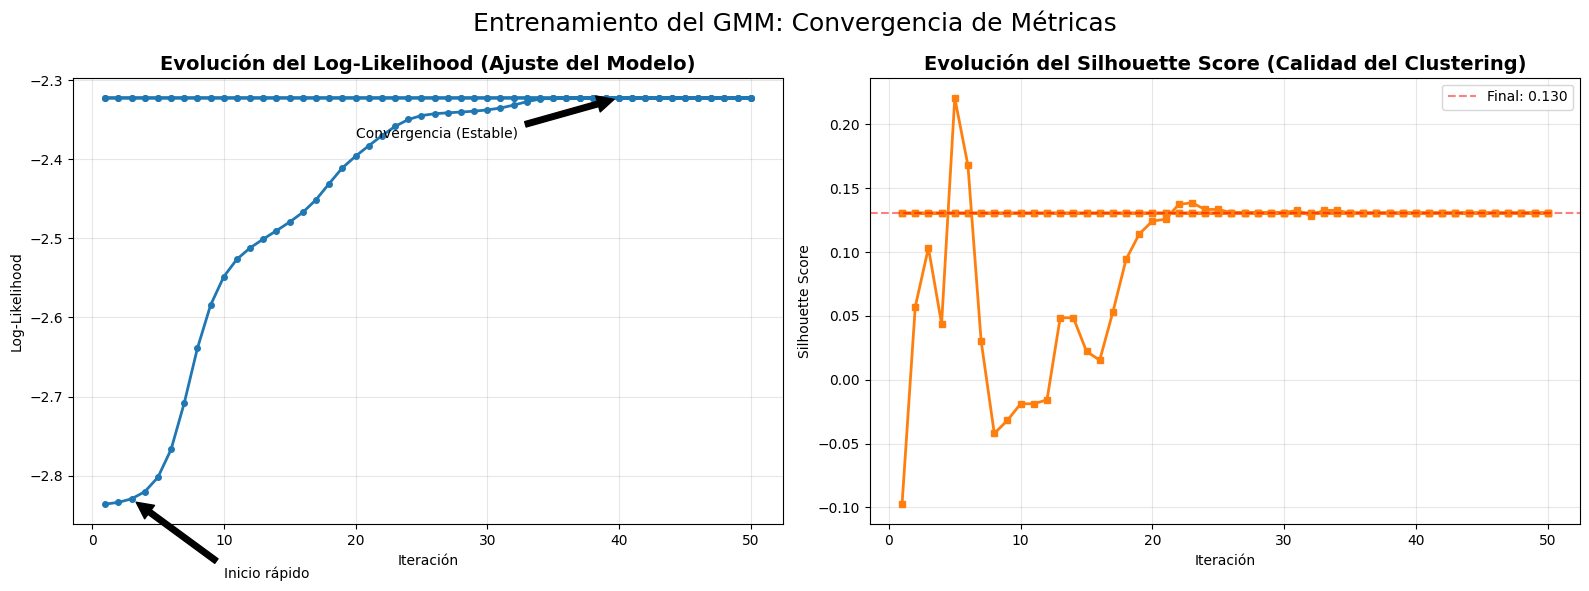

In [21]:

MAX_ITER = 50

for i in range(1, MAX_ITER + 1):
    gmm_metrics.fit(X_2d)

    # 1. Guardar Log-Likelihood (Score)
    # .score() devuelve el promedio del log-likelihood por muestra
    ll = gmm_metrics.score(X_2d)
    history_log_likelihood.append(ll)

    # 2. Guardar Silhouette Score
    labels = gmm_metrics.predict(X_2d)
    # Solo calculamos silhouette si hay más de 1 cluster (al inicio a veces asigna todo a uno)
    if len(np.unique(labels)) > 1:
        sil = silhouette_score(X_2d, labels)
    else:
        sil = -1 # Valor malo por defecto
    history_silhouette.append(sil)

    iterations.append(i)

print(f"¡Datos capturados! Log-Likelihood final: {history_log_likelihood[-1]:.4f}")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICA 1: LOG-LIKELIHOOD 
ax1.plot(iterations, history_log_likelihood, marker='o', markersize=4, color='#1f77b4', linewidth=2)
ax1.set_title('Evolución del Log-Likelihood (Ajuste del Modelo)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Iteración')
ax1.set_ylabel('Log-Likelihood')
ax1.grid(True, alpha=0.3)
ax1.annotate('Inicio rápido', xy=(3, history_log_likelihood[2]), xytext=(10, history_log_likelihood[2]-0.1),
             arrowprops=dict(facecolor='black', shrink=0.05))
ax1.annotate('Convergencia (Estable)', xy=(40, history_log_likelihood[-1]), xytext=(20, history_log_likelihood[-1]-0.05),
             arrowprops=dict(facecolor='black', shrink=0.05))

# --- GRÁFICA 2: SILHOUETTE SCORE 
ax2.plot(iterations, history_silhouette, marker='s', markersize=4, color='#ff7f0e', linewidth=2)
ax2.set_title('Evolución del Silhouette Score (Calidad del Clustering)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Iteración')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, alpha=0.3)
# Línea de referencia del valor final
ax2.axhline(y=history_silhouette[-1], color='red', linestyle='--', alpha=0.5, label=f'Final: {history_silhouette[-1]:.3f}')
ax2.legend()

plt.suptitle('Entrenamiento del GMM: Convergencia de Métricas', fontsize=18)
plt.tight_layout()
plt.show()

# Convergencia Optimizada: Inicialización mediante K-Means

En entornos productivos y profesionales, no se suele confiar en el azar para inicializar los centroides debido al riesgo de caer en óptimos locales (como vimos en algunos experimentos previos). El estándar de la industria es utilizar **K-Means** para encontrar primero la ubicación aproximada de los centros ($\mu$) y luego dejar que el algoritmo GMM refine las covarianzas ($\Sigma$).

### ¿Qué observar en esta secuencia?
A diferencia de la inicialización aleatoria, aquí observaremos una **estabilidad casi inmediata**:
1.  **Iteración 1:** Gracias a K-Means, el algoritmo comienza con los clusters ya ubicados correctamente.
2.  **Refinamiento de Covarianza:** De la iteración 1 a la 15, los cambios son sutiles pero matemáticamente cruciales. El modelo ya no "mueve" los centros, sino que ajusta la **forma y orientación** de las elipses para maximizar la verosimilitud final.
Esto demuestra por qué `init_params='kmeans'` es la configuración por defecto y recomendada: garantiza resultados robustos y reduce drásticamente el tiempo de cómputo necesario para converger.

In [16]:
# --- CONFIGURACIÓN K-MEANS (Estable desde el principio, solo ajusta covarianzas) ---
frames_kmeans = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 20]
# Nota: K-means converge rapidísimo, por eso miramos las primeras iteraciones seguidas
n_rows, n_cols = 4, 4

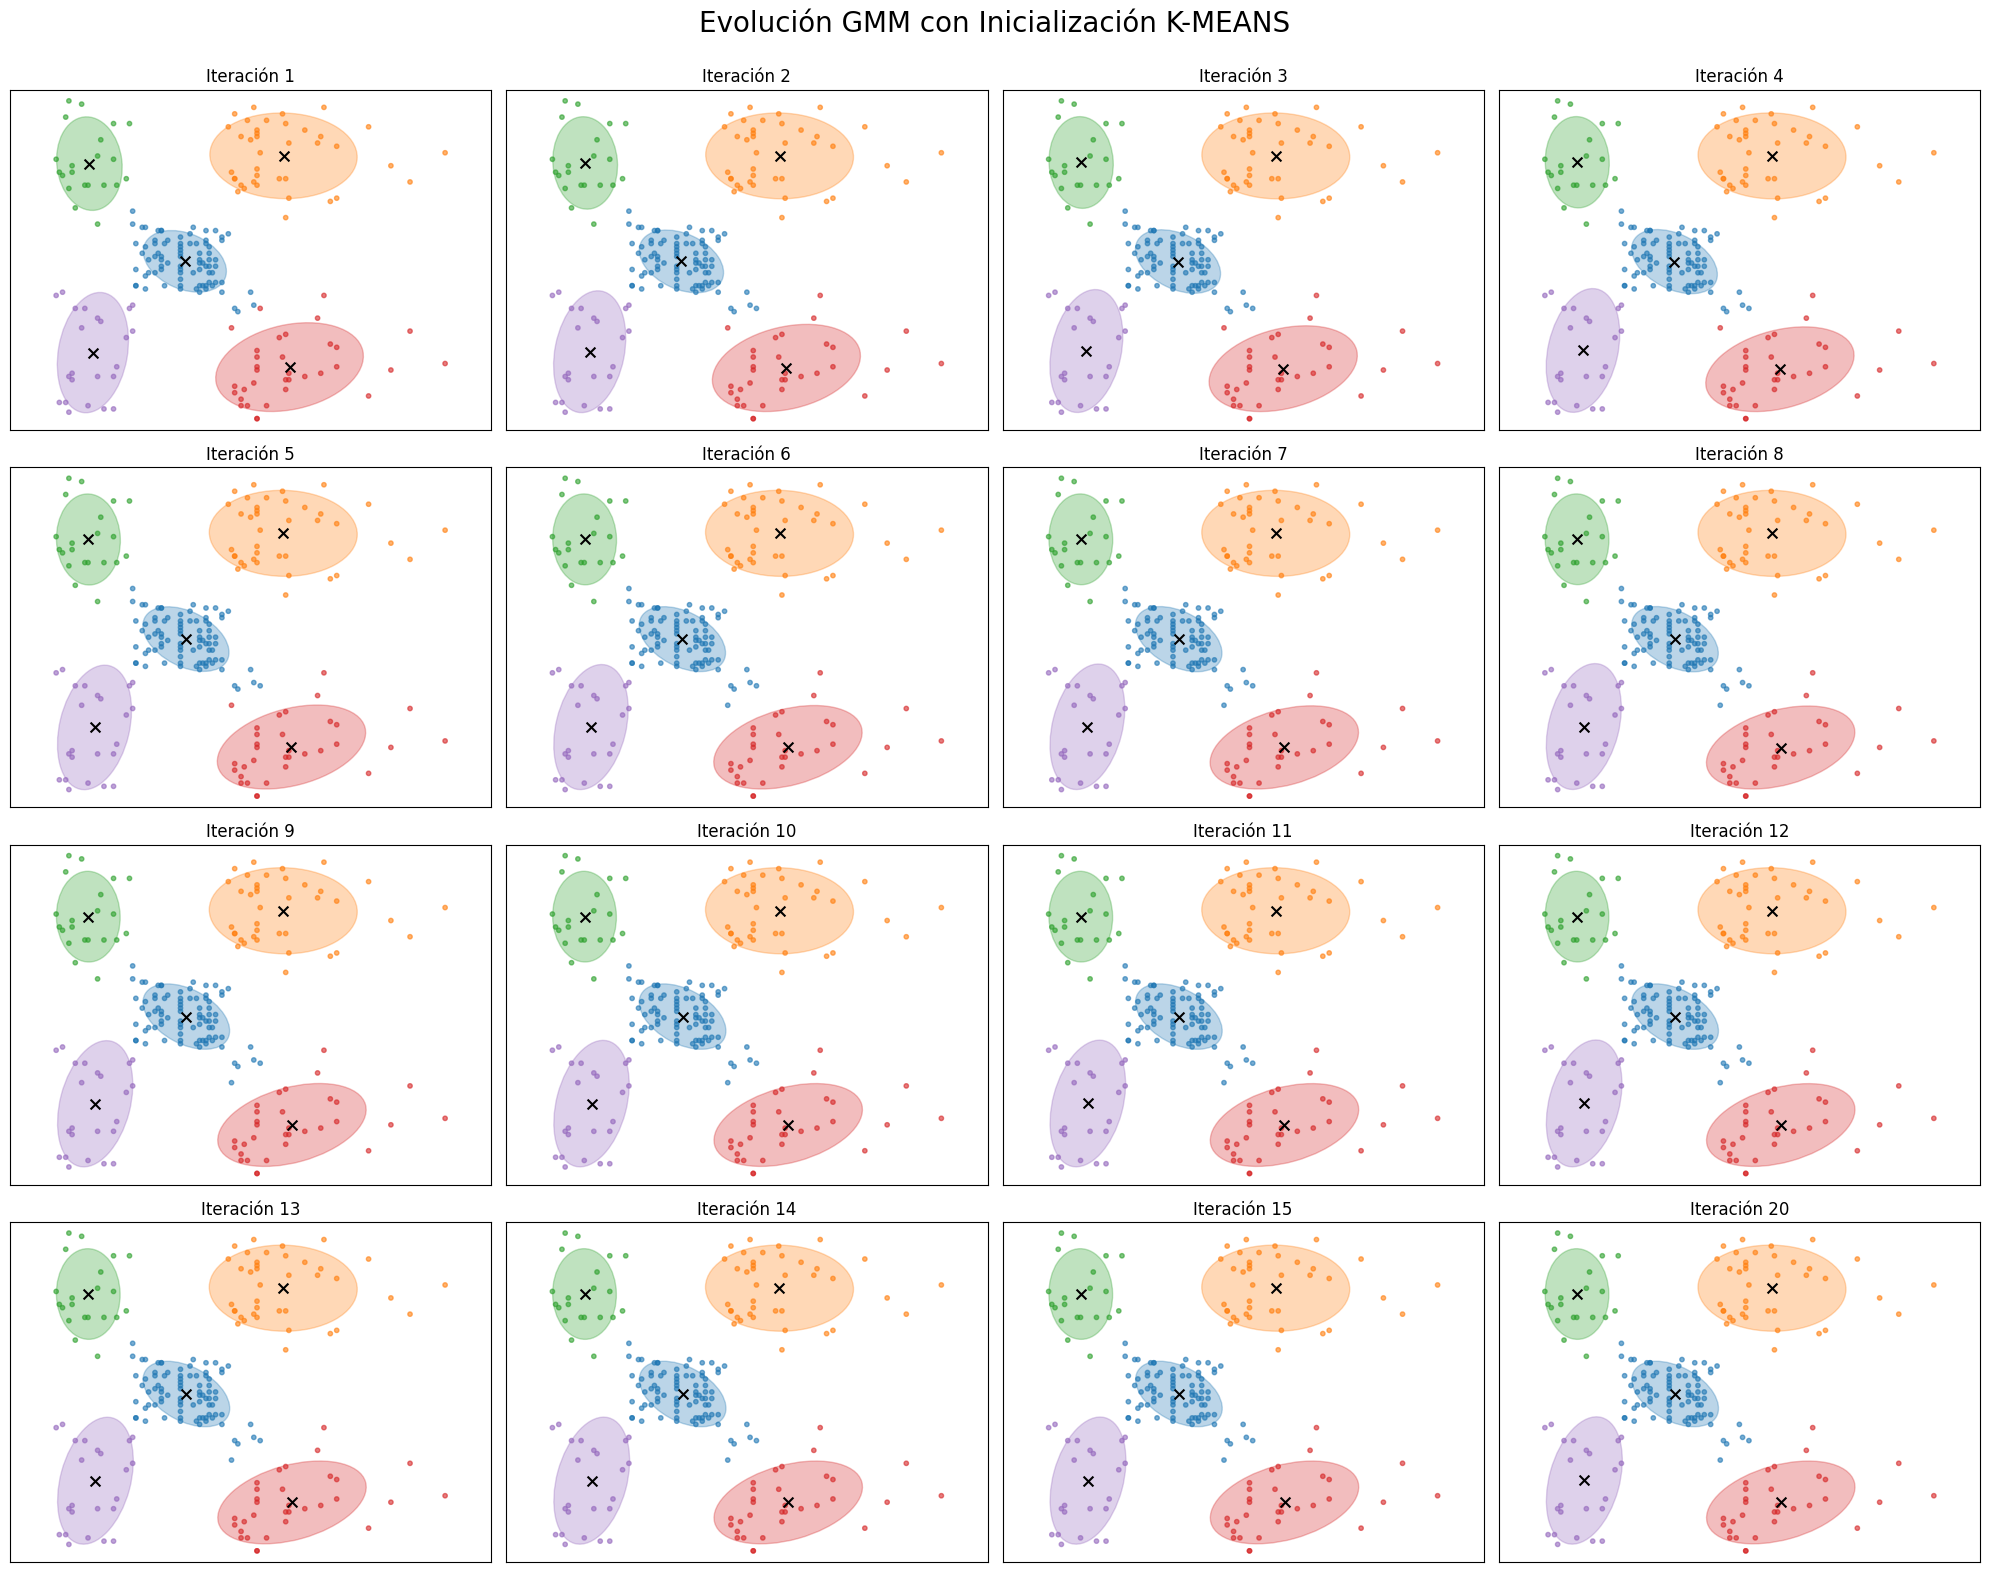

In [17]:
gmm_kmeans = GaussianMixture(n_components=5, random_state=42,
                             warm_start=True, max_iter=1, init_params='kmeans')

plt.figure(figsize=(20, 16))
current_iter = 0
plot_idx = 1
while plot_idx <= len(frames_kmeans):
    gmm_kmeans.fit(X_2d)
    current_iter += 1

    if current_iter in frames_kmeans:
        ax = plt.subplot(n_rows, n_cols, plot_idx)
        labels = gmm_kmeans.predict(X_2d)
        colors = [plt.cm.tab10(l) for l in labels]

        plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, s=10, alpha=0.6)
        make_ellipses(gmm_kmeans, ax)
        plt.scatter(gmm_kmeans.means_[:, 0], gmm_kmeans.means_[:, 1], c='black', marker='x', s=50, zorder=2)

        plt.title(f"Iteración {current_iter}")
        plt.xticks(())
        plt.yticks(())
        plot_idx += 1

plt.suptitle('Evolución GMM con Inicialización K-MEANS\n', fontsize=20)
plt.tight_layout()
plt.show()

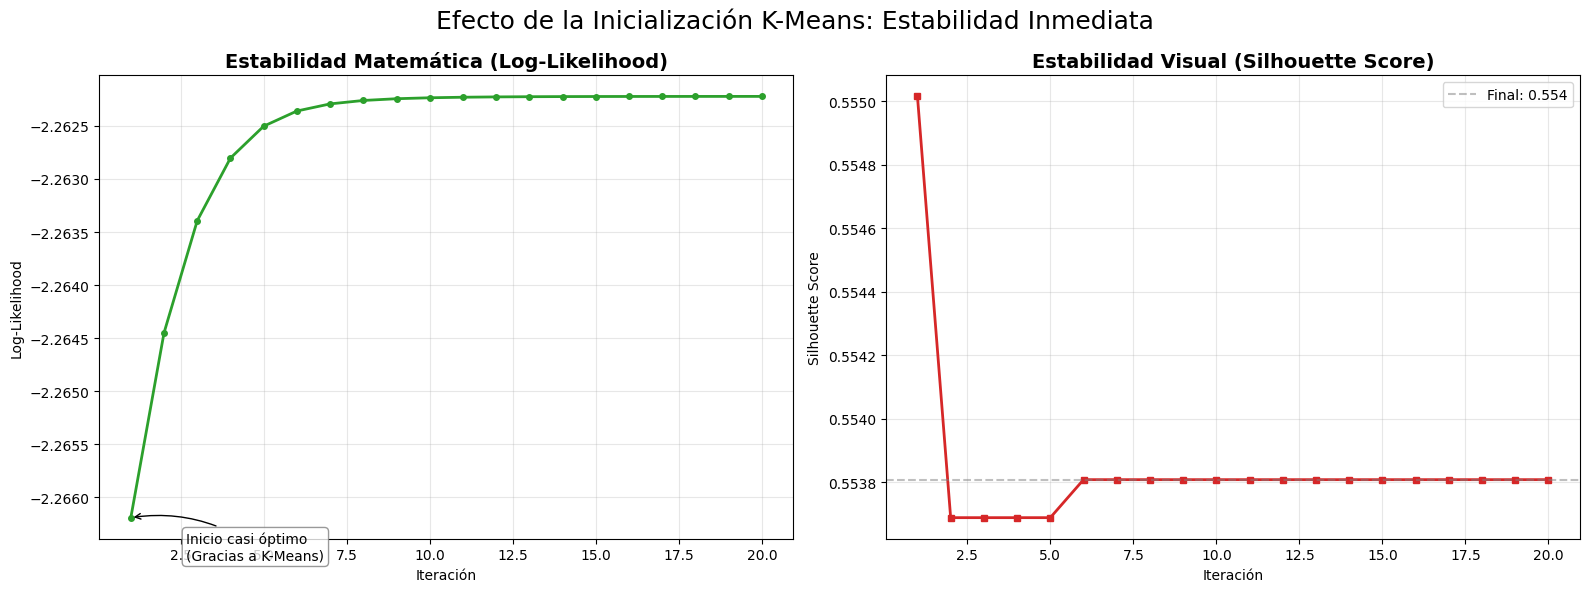

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# ============================================================================
# CORRECCIÓN: Captura de métricas con visualización robusta
# ============================================================================
# 1. Entrenar (Igual que antes)
gmm_kmeans_metrics = GaussianMixture(n_components=5, random_state=42,
                                     warm_start=True, max_iter=1, init_params='kmeans')

history_ll_kmeans = []
history_sil_kmeans = []
iterations_kmeans = []
MAX_ITER_KMEANS = 20

for i in range(1, MAX_ITER_KMEANS + 1):
    gmm_kmeans_metrics.fit(X_2d)
    history_ll_kmeans.append(gmm_kmeans_metrics.score(X_2d))

    labels = gmm_kmeans_metrics.predict(X_2d)
    if len(np.unique(labels)) > 1:
        sil = silhouette_score(X_2d, labels)
    else:
        sil = -1
    history_sil_kmeans.append(sil)
    iterations_kmeans.append(i)

# ============================================================================
# 2. GRAFICAR (ARREGLO DE FLECHAS)
# ============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICA 1: LOG-LIKELIHOOD ---
ax1.plot(iterations_kmeans, history_ll_kmeans, marker='o', markersize=4, color='#2ca02c', linewidth=2)
ax1.set_title('Estabilidad Matemática (Log-Likelihood)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Iteración')
ax1.set_ylabel('Log-Likelihood')
ax1.grid(True, alpha=0.3)

# ARREGLO AQUÍ: Usamos 'offset points' para que la flecha se mueva por píxeles
# xy: El punto exacto (Iteración 1, valor inicial)
# xytext: Dónde ponemos el texto (40 píxeles a la derecha, 20 abajo)
ax1.annotate('Inicio casi óptimo\n(Gracias a K-Means)',
             xy=(iterations_kmeans[0], history_ll_kmeans[0]),
             xytext=(40, -30),
             textcoords='offset points',
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2", color='black'),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# --- GRÁFICA 2: SILHOUETTE SCORE ---
ax2.plot(iterations_kmeans, history_sil_kmeans, marker='s', markersize=4, color='#d62728', linewidth=2)
ax2.set_title('Estabilidad Visual (Silhouette Score)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Iteración')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, alpha=0.3)

# Línea de referencia
final_sil = history_sil_kmeans[-1]
ax2.axhline(y=final_sil, color='grey', linestyle='--', alpha=0.5, label=f'Final: {final_sil:.3f}')
ax2.legend()

plt.suptitle('Efecto de la Inicialización K-Means: Estabilidad Inmediata', fontsize=18)
plt.tight_layout()
plt.show()

## GMM 3 variables

In [26]:
# ============================================================================
# 1. PREPARACIÓN DE DATOS (3 VARIABLES)
# ============================================================================
# Definimos el dataset de 3 dimensiones: Age, Income, Spending
# Asumimos que data_std ya existe y tiene estas columnas
X_all = data_std[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].values

# Definimos los datos 2D SOLO para visualizar (Income vs Spending)
# OJO: Income es el índice 1 y Spending el índice 2 en X_all
X_visual = data_std[['Annual Income (k$)', 'Spending Score (1-100)']].values

# ============================================================================
# 2. ANÁLISIS DE EVOLUCIÓN (ENTRENAMIENTO PASO A PASO)
# ============================================================================
print("Entrenando modelo GMM (3 Variables) paso a paso...")

# Configuración para capturar la evolución
gmm_3d = GaussianMixture(n_components=5,
                         random_state=42,
                         warm_start=True,
                         max_iter=1,
                         init_params='kmeans')

history_ll = []
history_sil = []
iterations = []
MAX_ITER = 20  # K-Means converge rápido

for i in range(1, MAX_ITER + 1):
    gmm_3d.fit(X_all)

    # Guardar Log-Likelihood
    history_ll.append(gmm_3d.score(X_all))

    # Guardar Silhouette Score (en espacio 3D)
    labels = gmm_3d.predict(X_all)
    if len(np.unique(labels)) > 1:
        sil = silhouette_score(X_all, labels)
    else:
        sil = -1
    history_sil.append(sil)
    iterations.append(i)

Entrenando modelo GMM (3 Variables) paso a paso...


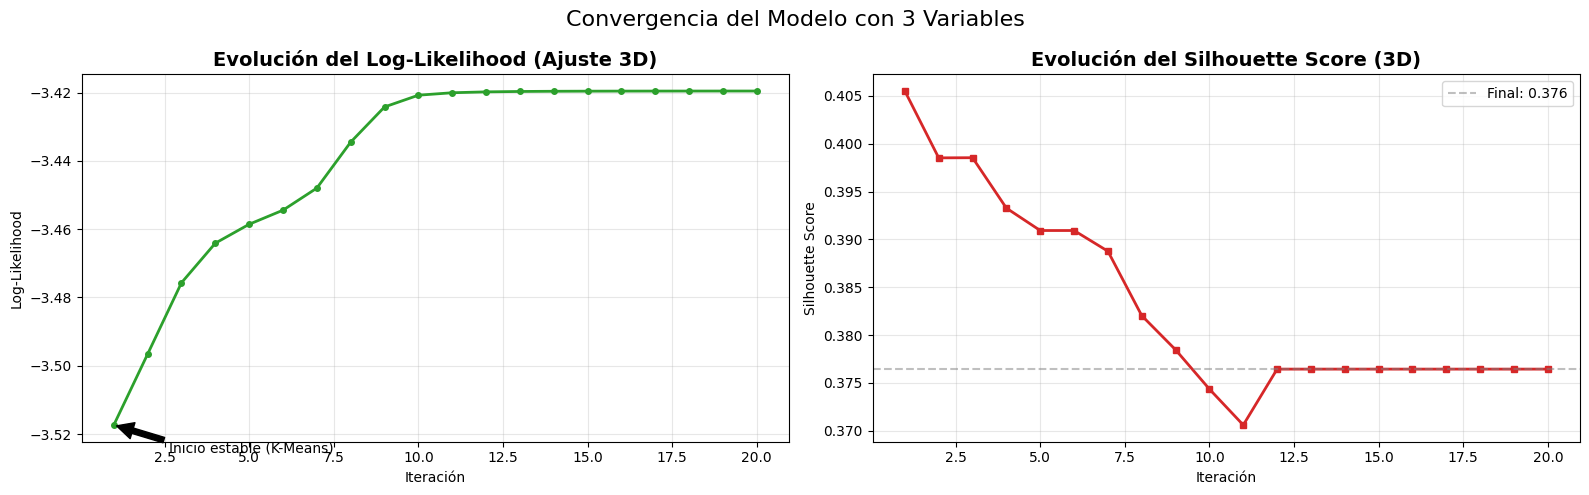

In [27]:
# ============================================================================
# 3. VISUALIZACIÓN DE MÉTRICAS DE EVOLUCIÓN
# ============================================================================
fig_evo, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# --- Gráfica 1: Log-Likelihood ---
ax1.plot(iterations, history_ll, marker='o', markersize=4, color='#2ca02c', linewidth=2)
ax1.set_title('Evolución del Log-Likelihood (Ajuste 3D)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Iteración')
ax1.set_ylabel('Log-Likelihood')
ax1.grid(True, alpha=0.3)
ax1.annotate('Inicio estable (K-Means)', xy=(1, history_ll[0]), xytext=(40, -20),
             textcoords='offset points', arrowprops=dict(facecolor='black', shrink=0.05))

# --- Gráfica 2: Silhouette Score ---
ax2.plot(iterations, history_sil, marker='s', markersize=4, color='#d62728', linewidth=2)
ax2.set_title('Evolución del Silhouette Score (3D)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Iteración')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=history_sil[-1], color='grey', linestyle='--', alpha=0.5, label=f'Final: {history_sil[-1]:.3f}')
ax2.legend()

plt.suptitle('Convergencia del Modelo con 3 Variables', fontsize=16)
plt.tight_layout()
plt.show()

In [28]:
# ============================================================================
# 4. MÉTRICAS FINALES Y HISTOGRAMA
# ============================================================================
labels_final = gmm_3d.predict(X_all)
probs_final = gmm_3d.predict_proba(X_all)

# --- Cálculo de Métricas ---
sil_final = silhouette_score(X_all, labels_final)
calinski = calinski_harabasz_score(X_all, labels_final)
davies = davies_bouldin_score(X_all, labels_final)
aic = gmm_3d.aic(X_all)
bic = gmm_3d.bic(X_all)

print("\n" + "="*50)
print("MÉTRICAS FINALES DEL MODELO (3 VARIABLES)")
print("="*50)
print(f"  - Silhouette Score:      {sil_final:.4f}")
print(f"  - Calinski-Harabasz:     {calinski:.4f}")
print(f"  - Davies-Bouldin:        {davies:.4f}")
print(f"  - AIC / BIC:             {aic:.0f} / {bic:.0f}")
print(f"  - Log-Likelihood Total:  {gmm_3d.score(X_all) * len(X_all):.0f}")


MÉTRICAS FINALES DEL MODELO (3 VARIABLES)
  - Silhouette Score:      0.3764
  - Calinski-Harabasz:     105.0181
  - Davies-Bouldin:        0.8902
  - AIC / BIC:             1466 / 1627
  - Log-Likelihood Total:  -684


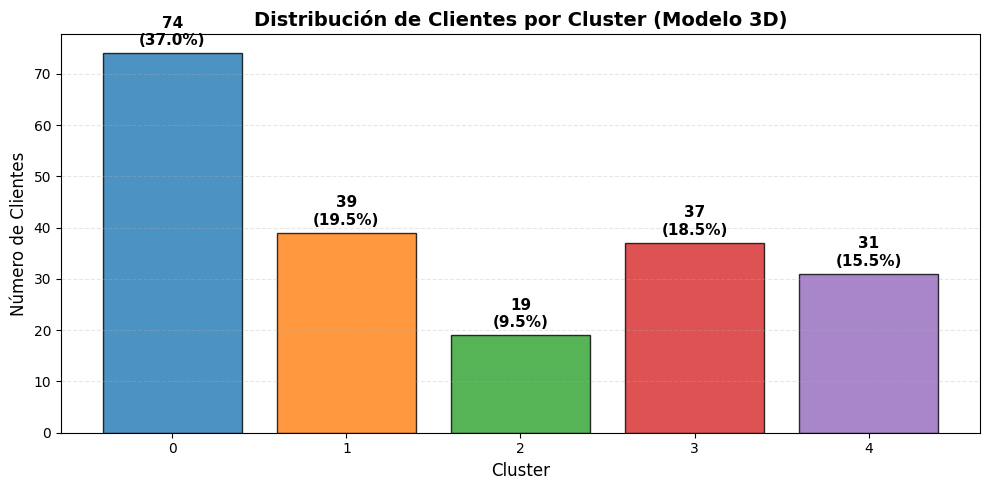

In [29]:
counts = pd.Series(labels_final).value_counts().sort_index()
colors = plt.cm.tab10(np.arange(5))

plt.figure(figsize=(10, 5))
bars = plt.bar(counts.index, counts.values, color=colors, alpha=0.8, edgecolor='black')
plt.title('Distribución de Clientes por Cluster (Modelo 3D)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.xticks(counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Porcentajes sobre las barras
for bar in bars:
    height = bar.get_height()
    pct = (height / len(X_all)) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{int(height)}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

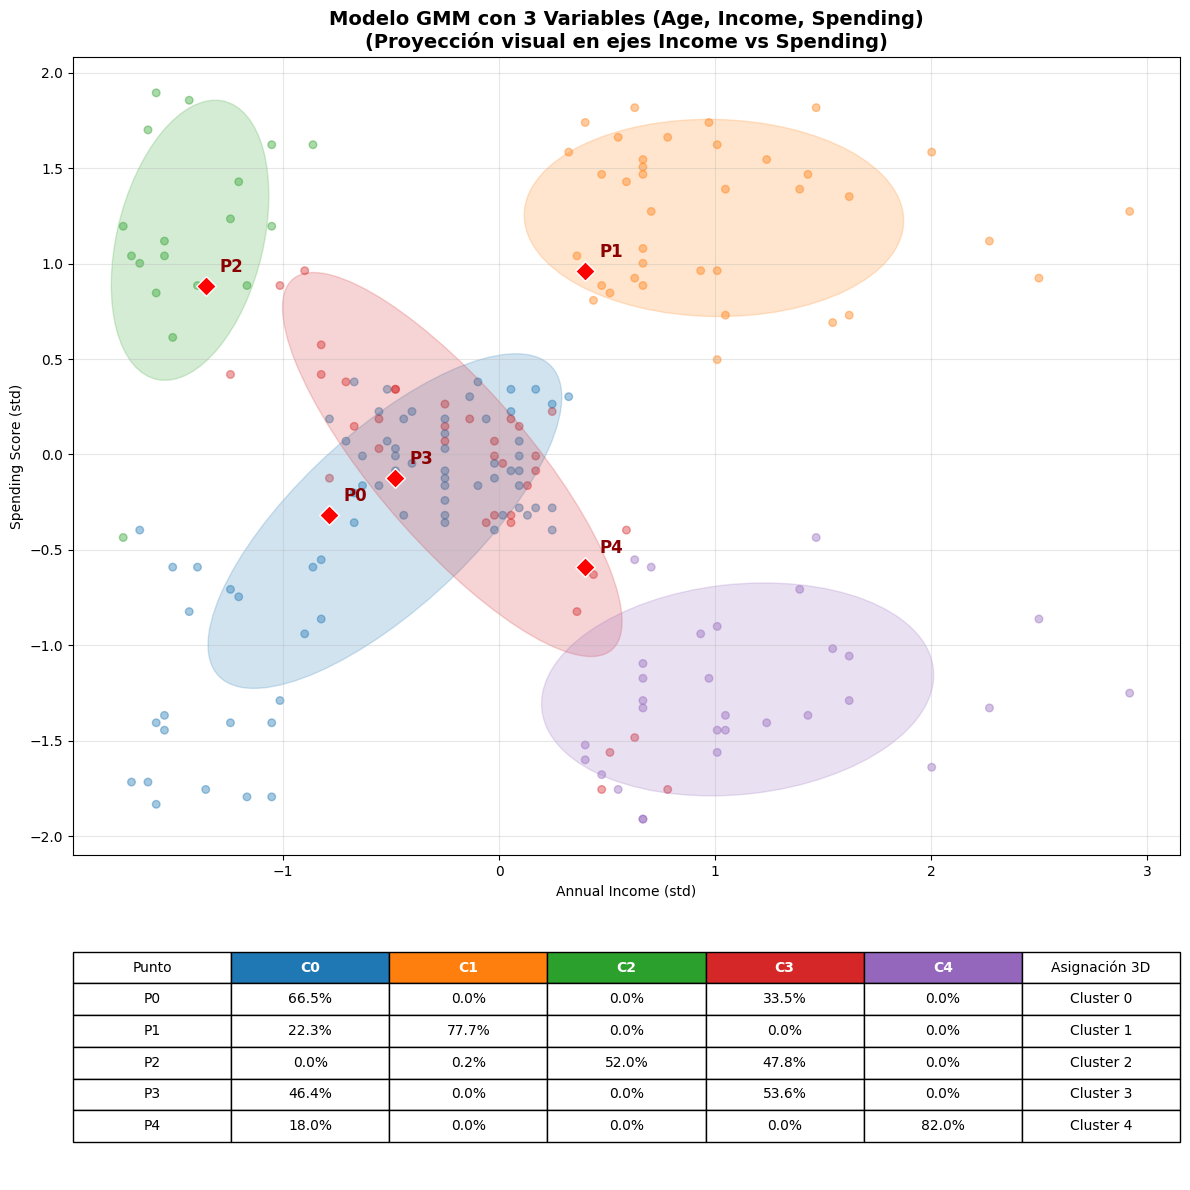

In [30]:
# ============================================================================
# 5. VISUALIZACIÓN FINAL: PROYECCIÓN 2D CON TABLA
# ============================================================================
# Selección de puntos testigo
witness_indices = []
for i in range(5):
    idx = np.where(labels_final == i)[0]
    if len(idx) > 0:
        max_probs = np.max(probs_final[idx], axis=1)
        witness_indices.append(idx[np.argmin(max_probs)])

witness_points_2d = X_visual[witness_indices]  # Para pintar
witness_probs = probs_final[witness_indices]   # Probabilidades reales

fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])
ax_plot = plt.subplot(gs[0])
ax_table = plt.subplot(gs[1])

point_colors = [colors[l] for l in labels_final]

# A) Scatter Plot
ax_plot.scatter(X_visual[:, 0], X_visual[:, 1], c=point_colors, s=30, alpha=0.4)

# B) Elipses Proyectadas (Income=1, Spending=2)
def draw_ellipses_projected(gmm, ax):
    for n, (mean, covar) in enumerate(zip(gmm.means_, gmm.covariances_)):
        # Extraemos submatriz para indices [1, 2]
        if gmm.covariance_type == 'full':
            cov = covar[np.ix_([1, 2], [1, 2])]
        elif gmm.covariance_type == 'diag':
            cov = np.diag([covar[1], covar[2]])

        v, w = np.linalg.eigh(cov)
        u = w[0] / np.linalg.norm(w[0])
        angle = np.arctan2(u[1], u[0]) * 180 / np.pi
        v = 2. * np.sqrt(2.) * np.sqrt(v)

        # Medias de Income (1) y Spending (2)
        mean_proj = mean[[1, 2]]

        ell = mpl_patches.Ellipse(mean_proj, v[0], v[1], angle=180+angle, color=colors[n], alpha=0.2)
        ax.add_artist(ell)

draw_ellipses_projected(gmm_3d, ax_plot)

# C) Puntos Testigo
ax_plot.scatter(witness_points_2d[:, 0], witness_points_2d[:, 1], c='red', marker='D', s=100, edgecolors='white', zorder=10)
for i, txt in enumerate([f'P{k}' for k in range(len(witness_indices))]):
    ax_plot.annotate(txt, (witness_points_2d[i, 0], witness_points_2d[i, 1]),
                     xytext=(10, 10), textcoords='offset points',
                     weight='bold', fontsize=12, color='darkred', zorder=11)

ax_plot.set_title('Modelo GMM con 3 Variables (Age, Income, Spending)\n(Proyección visual en ejes Income vs Spending)', fontsize=14, fontweight='bold')
ax_plot.set_xlabel('Annual Income (std)')
ax_plot.set_ylabel('Spending Score (std)')
ax_plot.grid(True, alpha=0.3)

# D) Tabla
ax_table.axis('tight')
ax_table.axis('off')
table_data = []
for i in range(len(witness_indices)):
    row = [f"P{i}"]
    probs_perc = [f"{p*100:.1f}%" for p in witness_probs[i]]
    row.extend(probs_perc)
    row.append(f"Cluster {np.argmax(witness_probs[i])}")
    table_data.append(row)

column_labels = ['Punto', 'C0', 'C1', 'C2', 'C3', 'C4', 'Asignación 3D']
cluster_colors_hex = [mpl_patches.colors.to_hex(c) for c in colors]

table = ax_table.table(cellText=table_data, colLabels=column_labels, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

for i in range(5):
    cell = table[0, i+1]
    cell.set_facecolor(cluster_colors_hex[i])
    cell.set_text_props(color='white', weight='bold')

plt.tight_layout()
plt.show()

### Gif generator

In [23]:
def save_frame(gmm, iteration, title_prefix, folder, filename):
    fig, ax = plt.subplots(figsize=(9, 7))

    # Dibujar Puntos
    labels = gmm.predict(X_2d)
    colors = plt.cm.tab10(np.arange(5))
    point_colors = [colors[l] for l in labels]
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=point_colors, s=30, alpha=0.5, zorder=1)

    # Dibujar Elipses
    for n, (mean, covar, weight) in enumerate(zip(gmm.means_, gmm.covariances_, gmm.weights_)):
        if gmm.covariance_type == 'full': covariances = covar[:2, :2]
        elif gmm.covariance_type == 'tied': covariances = gmm.covariances_[:2, :2]
        elif gmm.covariance_type == 'diag': covariances = np.diag(covar[:2])
        elif gmm.covariance_type == 'spherical': covariances = np.eye(gmm.means_.shape[1]) * covar

        v, w = np.linalg.eigh(covariances)
        u = w[0] / np.linalg.norm(w[0])
        angle = np.arctan2(u[1], u[0])
        angle = 180 * angle / np.pi
        v = 2. * np.sqrt(2.) * np.sqrt(v)

        ell = mpl_patches.Ellipse(mean, v[0], v[1], angle=180 + angle, color=colors[n])
        ell.set_clip_box(ax.bbox)
        ell.set_alpha(0.3)
        ax.add_artist(ell)

    # Centroides
    ax.scatter(gmm.means_[:, 0], gmm.means_[:, 1], c='black', s=80, marker='X', zorder=2)

    plt.title(f'{title_prefix} - Iteración: {iteration}', fontsize=14)
    plt.xlabel('Annual Income (Std)')
    plt.ylabel('Spending Score (Std)')
    plt.grid(True, alpha=0.3)

    # Guardar
    path = os.path.join(folder, filename)
    plt.savefig(path, dpi=80)
    plt.close(fig)

print("Funciones y datos cargados.")

Funciones y datos cargados.


In [25]:
# --- CONFIGURACIÓN CASO 1: RANDOM ---
CASE_NAME = "Random Init"
FOLDER = "frames_random"
GIF_NAME = "gmm_random_evolution.gif"
SEMILLA = 2       # Usamos la semilla 2 que viaja bien
MAX_ITER = 60     # Necesita tiempo para viajar
FPS = 2           # Frames por segundo (Velocidad)

if not os.path.exists(FOLDER): os.makedirs(FOLDER)

print(f"Generando frames para {CASE_NAME}...")
gmm_rand = GaussianMixture(n_components=5, random_state=SEMILLA,
                           warm_start=True, max_iter=1, init_params='random')

filenames = []
for i in range(1, MAX_ITER + 1):
    gmm_rand.fit(X_2d)
    fname = f"frame_{i:03d}.png"
    save_frame(gmm_rand, i, CASE_NAME, FOLDER, fname)
    filenames.append(os.path.join(FOLDER, fname))
    if i % 10 == 0: print(f"  -> {i}/{MAX_ITER}")

# Crear GIF
print("Creando GIF Random...")
images = [imageio.imread(f) for f in filenames]
# Añadir pausa final (10 copias del último frame)
for _ in range(10): images.append(images[-1])
imageio.mimsave(GIF_NAME, images, duration=0.6) # 0.4s por frame
print(f"¡LISTO! {GIF_NAME}")

Generando frames para Random Init...
  -> 10/60
  -> 20/60
  -> 30/60
  -> 40/60
  -> 50/60
  -> 60/60
Creando GIF Random...
¡LISTO! gmm_random_evolution.gif


In [27]:
# --- CONFIGURACIÓN CASO 2: K-MEANS ---
CASE_NAME = "K-Means Init"
FOLDER = "frames_kmeans"
GIF_NAME = "gmm_kmeans_evolution.gif"
SEMILLA = 42      # La semilla importa menos aquí
MAX_ITER = 15     # Converge rapidísimo
FPS = 2

if not os.path.exists(FOLDER): os.makedirs(FOLDER)

print(f"Generando frames para {CASE_NAME}...")
gmm_km = GaussianMixture(n_components=5, random_state=SEMILLA,
                         warm_start=True, max_iter=1, init_params='kmeans')

filenames = []
for i in range(1, MAX_ITER + 1):
    gmm_km.fit(X_2d)
    fname = f"frame_{i:03d}.png"
    save_frame(gmm_km, i, CASE_NAME, FOLDER, fname)
    filenames.append(os.path.join(FOLDER, fname))
    print(f"  -> {i}/{MAX_ITER}")

# Crear GIF
print("Creando GIF K-Means...")
images = [imageio.imread(f) for f in filenames]
# Añadir pausa final
for _ in range(10): images.append(images[-1])
imageio.mimsave(GIF_NAME, images, duration=0.8) # Más lento para ver los micro-ajustes
print(f"¡LISTO!{GIF_NAME}")

Generando frames para K-Means Init...
  -> 1/15
  -> 2/15
  -> 3/15
  -> 4/15
  -> 5/15
  -> 6/15
  -> 7/15
  -> 8/15
  -> 9/15
  -> 10/15
  -> 11/15
  -> 12/15
  -> 13/15
  -> 14/15
  -> 15/15
Creando GIF K-Means...
¡LISTO!gmm_kmeans_evolution.gif
